<a href="https://colab.research.google.com/github/Mubby03/Machine-Deep-Learning-Pancakes/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("Practical Regression")

Welcome to Practical Regression


# Regression Example

In [ ]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
housing = pd.read_csv('housing.csv')
housing.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129,322,126,8.3252,3,452600
1,-122.22,37.86,21,7099,1106,2401,1138,8.3014,3,358500
2,-122.24,37.85,52,1467,190,496,177,7.2574,3,352100
3,-122.25,37.85,52,1274,235,558,219,5.6431,3,341300
4,-122.25,37.85,52,1627,280,565,259,3.8462,3,342200


In [ ]:
housing.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
ocean_proximity,0
median_house_value,0


In [ ]:
X = housing.drop('median_house_value', axis=1)
print('The values of the inputs are :',X)
y = housing['median_house_value']
print('The values of target are :',y)

The values of the inputs are :        longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -122.23     37.88                  41          880             129   
1        -122.22     37.86                  21         7099            1106   
2        -122.24     37.85                  52         1467             190   
3        -122.25     37.85                  52         1274             235   
4        -122.25     37.85                  52         1627             280   
...          ...       ...                 ...          ...             ...   
20635    -121.09     39.48                  25         1665             374   
20636    -121.21     39.49                  18          697             150   
20637    -121.22     39.43                  17         2254             485   
20638    -121.32     39.43                  18         1860             409   
20639    -121.24     39.37                  16         2785             616   

       population  h

In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [ ]:
min_max_scaler = preprocessing.MinMaxScaler()
X_train=min_max_scaler.fit_transform(X_train)
X_test=min_max_scaler.transform(X_test)

In [ ]:
regressor=LinearRegression()
regressor.fit(X_train,Y_train)
y_reg_pred=regressor.predict(X_test)
reg_test=r2_score(Y_test,y_reg_pred)
print('R² score linear Regressor on testing set',reg_test)
print('Mean Squared Error: {:.2f}'.format(metrics.mean_squared_error(Y_test, y_reg_pred)))
print('Root Mean Squared Error: {:.2f}'.format(np.sqrt(metrics.mean_squared_error(Y_test, y_reg_pred))))


R² score linear Regressor on testing set 0.6268370213585921
Mean Squared Error: 4916724097.42
Root Mean Squared Error: 70119.36


In [ ]:
knn = KNeighborsRegressor()
knn.fit(X_train, Y_train)
y_knn_pred=knn.predict(X_test)
knn_test=r2_score(Y_test,y_knn_pred)
print('R² score for KNN on testing set',knn_test)
print('Mean Squared Error: {:.2f}'.format(metrics.mean_squared_error(Y_test,y_knn_pred)))
print('Root Mean Squared Error: {:.2f}'.format(np.sqrt(metrics.mean_squared_error(Y_test,y_knn_pred))))

R² score for KNN on testing set 0.6971276638411987
Mean Squared Error: 3990588024.18
Root Mean Squared Error: 63171.10


In [ ]:
svr = SVR(kernel='poly')
svr.fit(X_train, Y_train)
y_svr_pred=svr.predict(X_test)
svr_test=r2_score(Y_test,y_svr_pred)
print('R² score for SVR on testing set',svr_test)
print('Mean Squared Error: {:.2f}'.format(metrics.mean_squared_error(Y_test,y_svr_pred)))
print('Root Mean Squared Error: {:.2f}'.format(np.sqrt(metrics.mean_squared_error(Y_test,y_svr_pred))))

R² score for SVR on testing set -0.01440626624357666
Mean Squared Error: 13365623117.20
Root Mean Squared Error: 115609.79


In [ ]:
tree = DecisionTreeRegressor()
tree.fit(X_train, Y_train)
y_DT_pred=tree.predict(X_test)
tree_test=r2_score(Y_test,y_DT_pred)
print('R² score for Tree on testing set',tree_test)
print('Mean Squared Error: {:.2f}'.format(metrics.mean_squared_error(Y_test,y_DT_pred)))
print('Root Mean Squared Error: {:.2f}'.format(np.sqrt(metrics.mean_squared_error(Y_test,y_DT_pred))))

R² score for Tree on testing set 0.6351080865022932
Mean Squared Error: 4807746123.63
Root Mean Squared Error: 69337.91


In [ ]:
gb = GradientBoostingRegressor(random_state=0)
gb.fit(X_train, Y_train)
y_gb_pred=gb.predict(X_test)
gb_test=r2_score(Y_test,y_gb_pred)
print('R² score for Gradientboost on testing set',gb_test)
print('Mean Squared Error: {:.2f}'.format(metrics.mean_squared_error(Y_test,y_gb_pred)))
print('Root Mean Squared Error: {:.2f}'.format(np.sqrt(metrics.mean_squared_error(Y_test,y_gb_pred))))

R² score for Gradientboost on testing set 0.767762558464464
Mean Squared Error: 3059916150.52
Root Mean Squared Error: 55316.51


In [ ]:
Rf = RandomForestRegressor()
Rf.fit(X_train,Y_train)
y_rf_pred=Rf.predict(X_test)
rf_test=r2_score(Y_test,y_rf_pred)
print('R² score for Gradientboost on testing set',rf_test)
print('Mean Squared Error: {:.2f}'.format(metrics.mean_squared_error(Y_test,y_rf_pred)))
print('Root Mean Squared Error: {:.2f}'.format(np.sqrt(metrics.mean_squared_error(Y_test,y_rf_pred))))

R² score for Gradientboost on testing set 0.8129299023185623
Mean Squared Error: 2464799859.10
Root Mean Squared Error: 49646.75


In [ ]:
models = ['KNN Regressor', 'Linear Regression', 'Support Vector Regression','Decision Tree Regressor' ,'Random Forest Regressor', 'Gradient Boosting Regressor']
tests_score = [knn_test,reg_test,svr_test,tree_test, gb_test,rf_test]
compare_models = pd.DataFrame({ 'Algorithms': models, 'Tests Score': tests_score })
compare_models.sort_values(by = 'Tests Score', ascending = False)

,Algorithms,Tests Score
5,Gradient Boosting Regressor,0.812930
4,Random Forest Regressor,0.767763
0,KNN Regressor,0.697128
3,Decision Tree Regressor,0.635108
1,Linear Regression,0.626837
2,Support Vector Regression,-0.014406


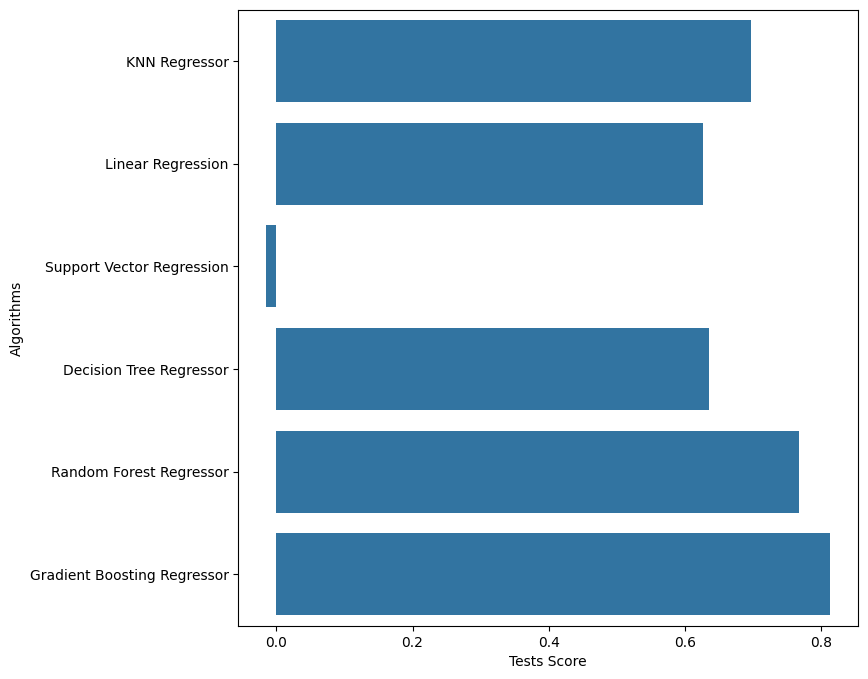

In [ ]:
plt.figure(figsize=(8,8))
TestsScore=tests_score
sns.barplot(x = 'Tests Score', y = 'Algorithms', data = compare_models)
plt.show()